# 2.3 — The dot product, at the computer

Worksheet first. Then this: see the aligned/perpendicular/opposite story in colour,
and run a real similarity search — the seed of attention.

In [1]:
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import axes_through_origin

In [2]:
# The dot product three ways — all the same number.
a = np.array([2, 3])
b = np.array([4, 1])

# Way 1: by hand, exactly like on paper
total = 0
for i in range(len(a)):        # i = 0, then 1
    total = total + a[i] * b[i]
print("loop:      ", total)

# Way 2: element-wise multiply (a VECTOR), then sum it
print("a * b      =", a * b, "  <- NOT the dot product yet — still a vector!")
print("sum(a * b) =", np.sum(a * b))

# Way 3: the @ operator — numpy's dot product. This is the one you'll use forever.
print("a @ b      =", a @ b)

loop:       11
a * b      = [8 3]   <- NOT the dot product yet — still a vector!
sum(a * b) = 11
a @ b      = 11


## 1. The sign story, in colour

Fix one vector (black). Dot it with arrows pointing every which way, and colour each arrow by
its score. Watch the lesson's table come alive: **same way = hot, right angles = zero, opposite = cold.**

(The `np.cos`/`np.sin` below just walks evenly around a circle — no trig needed, it's a compass.)

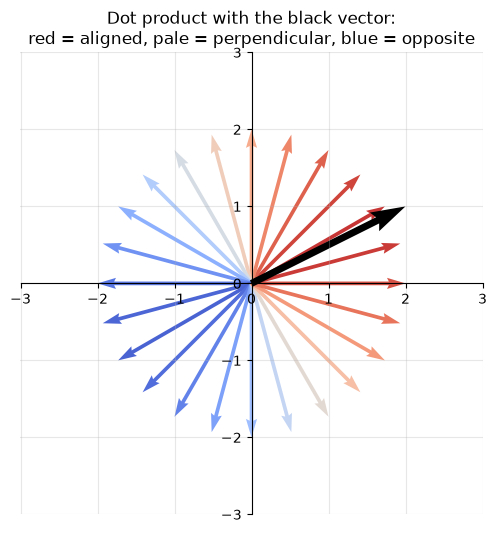

In [3]:
fixed = np.array([2.0, 1.0])

ax = axes_through_origin(xlim=(-3, 3), ylim=(-3, 3))
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)   # 24 directions around a circle
for t in angles:
    v = 2 * np.array([np.cos(t), np.sin(t)])             # an arrow of length 2, direction t
    score = fixed @ v
    colour = plt.cm.coolwarm((score + 5) / 10)           # map score -5..5 onto blue..red
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
              color=colour, width=0.008)
ax.quiver(0, 0, fixed[0], fixed[1], angles="xy", scale_units="xy", scale=1,
          color="black", width=0.015)
ax.set_title("Dot product with the black vector:\nred = aligned, pale = perpendicular, blue = opposite")
plt.show()
# Find the palest arrows. What angle do they make with the black one?

## 2. Similarity search — attention's first half

Toy word vectors, axes = (animal-ness, machine-ness, size). A query comes in;
we score every word against it with **cosine similarity** and rank.
This dot-then-rank move is the beating heart of semantic search *and* transformer attention.

In [4]:
words = {
    "kitten":  np.array([9.0, 0.0, 1.0]),
    "tiger":   np.array([9.0, 0.0, 6.0]),
    "tractor": np.array([0.0, 9.0, 7.0]),
    "drone":   np.array([0.0, 8.0, 2.0]),
    "robot dog": np.array([4.0, 7.0, 3.0]),
}

def cosine(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))   # dot, divided by both lengths

query = np.array([8.0, 1.0, 2.0])    # 'small-ish animal, barely mechanical'

scores = {name: cosine(query, vec) for name, vec in words.items()}
for name, s in sorted(scores.items(), key=lambda kv: -kv[1]):   # sort by score, biggest first
    print(f"{name:10s} {s:.3f}  {'#' * int(s * 20)}")
# The ranking IS the answer to 'which words are most like my query?'

kitten     0.984  ###################
tiger      0.935  ##################
robot dog  0.630  ############
tractor    0.243  ####
drone      0.175  ###


In [5]:
# YOUR TURN
# 1) Verify worksheet Part A with @ — one is done:
print(np.array([3, 2]) @ np.array([4, 5]))    # should match your hand answer to A1

# 2) Worksheet C9: print  a * b  and  a @ b  for a=[2,3], b=[4,5]. Which one did the
#    error-maker compute?

# 3) Worksheet D13 (query and three keys): compute all three scores with @ and check your ranking.

# 4) Design a query vector that would rank 'tractor' FIRST in the search above, and prove it.

22


In [6]:
# 🌀 The worksheet's deep-end question, answered by experiment:
# in HIGH dimensions, random arrows are almost always nearly perpendicular.
rng = np.random.default_rng(42)

for dim in [2, 10, 100, 768]:
    sims = []
    for _ in range(200):                      # 200 random pairs per dimension
        u = rng.standard_normal(dim)          # a random arrow in dim-D space
        v = rng.standard_normal(dim)
        sims.append((u @ v) / (np.linalg.norm(u) * np.linalg.norm(v)))
    print(f"{dim:4d}-D: average |cosine similarity| of random pairs = {np.mean(np.abs(sims)):.3f}")
# 2-D arrows collide constantly; 768-D arrows barely notice each other.
# That's WHY high-dimensional embeddings work: there's room for every concept
# to have its own direction. Mathematicians call it 'the blessing of dimensionality'.

   2-D: average |cosine similarity| of random pairs = 0.663
  10-D: average |cosine similarity| of random pairs = 0.269
 100-D: average |cosine similarity| of random pairs = 0.074
 768-D: average |cosine similarity| of random pairs = 0.027


---
*Photograph your worksheet into `scans/inbox/`. Next: 2.4 — matrices. You already know their
secret: every row of a matrix is about to dot-product your vectors.*